# **11. Emotion Sentiment Analysis**

### **11.1 Clean Data Load**

In [ ]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

file_path = "/content/drive/My Drive/Major Project/clean_dataset.csv"
df_final = pd.read_csv(file_path)

Mounted at /content/drive


In [ ]:
df_final

,clean_text,language,Category,VADER_Compound
0,dear vaccine advocate do take the covid19 mrna...,en,Negative,-0.6757
1,world at least 6 dead and 16 injured in russia...,es,Negative,-0.7906
2,animal shelter dogs and cats we need your help...,en,Positive,0.8225
3,welcome to our shelter located in ukraine kyiv...,en,Positive,0.6908
4,tension because russia is still standing at th...,es,Negative,-0.5423
...,...,...,...,...
45181,not about me because i would never dare fortun...,uk,Neutral,0.0000
45182,everything as usual just another russian gover...,en,Positive,0.4215
45183,roulette ep7 ukraine president zelensky the he...,es,Neutral,0.0000
45184,roulette ep7 ukraine president zelensky the he...,es,Neutral,0.0000


### **11.2 Emotion Classification Pipeline**

In [ ]:
from transformers import pipeline

emotion = pipeline(
    "text-classification",
    model="bhadresh-savani/distilbert-base-uncased-emotion",
    return_all_scores=True,
    device=0)

config.json:   0%|          | 0.00/768 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
want to see like this df_final[['clean_text','emotion','score']].head(10) before this what step to do

In [ ]:
texts = df_final["clean_text"].astype(str).tolist()

results = []

for i in range(0, len(texts), 128):
    batch = texts[i:i+128]
    batch_results = emotion(batch)
    results.extend(batch_results)

df_final[["emotion", "Score"]] = [(r["label"], r["score"]) for r in results]
df_final[['clean_text','emotion','Score']].head(10)

,clean_text,emotion,Score
0,dear vaccine advocate do take the covid19 mrna...,joy,0.676632
1,world at least 6 dead and 16 injured in russia...,fear,0.945299
2,animal shelter dogs and cats we need your help...,joy,0.980893
3,welcome to our shelter located in ukraine kyiv...,joy,0.863962
4,tension because russia is still standing at th...,anger,0.976691
5,good news you may have missed first shipment o...,fear,0.789129
6,opinion the ukraine war is also being fought o...,anger,0.98516
7,ale fuck tt ou putin haitian creole istandwith...,anger,0.983975
8,ethereums spot setup looks grim but derivative...,sadness,0.996903
9,article by jeffreydsachs biden is leading ukra...,joy,0.93297


### **11.3 Count of Each Emotion**

In [ ]:
df_final['emotion'].value_counts()

,count
emotion,
anger,18496
joy,17259
fear,5506
sadness,3382
love,328
surprise,215


### **11.4 Save Emotion Data**

In [ ]:
df_final.to_csv("/content/drive/My Drive/Major Project/clean_dataset_emotion.csv", index=False)

### **11.5 Import Emotion Data**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

file_path = "/content/drive/My Drive/Major Project/clean_dataset_emotion.csv"
df_final = pd.read_csv(file_path)

Mounted at /content/drive


In [ ]:
df_final

,clean_text,language,Category,VADER_Compound,emotion,Score
0,dear vaccine advocate do take the covid19 mrna...,en,Negative,-0.6757,joy,0.676632
1,world at least 6 dead and 16 injured in russia...,es,Negative,-0.7906,fear,0.945299
2,animal shelter dogs and cats we need your help...,en,Positive,0.8225,joy,0.980893
3,welcome to our shelter located in ukraine kyiv...,en,Positive,0.6908,joy,0.863962
4,tension because russia is still standing at th...,es,Negative,-0.5423,anger,0.976691
...,...,...,...,...,...,...
45181,not about me because i would never dare fortun...,uk,Neutral,0.0000,joy,0.991096
45182,everything as usual just another russian gover...,en,Positive,0.4215,joy,0.966337
45183,roulette ep7 ukraine president zelensky the he...,es,Neutral,0.0000,anger,0.717840
45184,roulette ep7 ukraine president zelensky the he...,es,Neutral,0.0000,anger,0.717840


### **11.6 Emotion Summary**

In [ ]:
emotion_summary = (df_final['emotion'].value_counts().reset_index())
emotion_summary.columns = ['Emotions', 'Count']
emotion_summary['Proportion(%)'] = (emotion_summary['Count'] / emotion_summary['Count'].sum() * 100).round(2)

emotion_summary

,Emotions,Count,Proportion(%)
0,anger,18496,40.93
1,joy,17259,38.20
2,fear,5506,12.19
3,sadness,3382,7.48
4,love,328,0.73
5,surprise,215,0.48


### **11.7 Emotion Distribution**

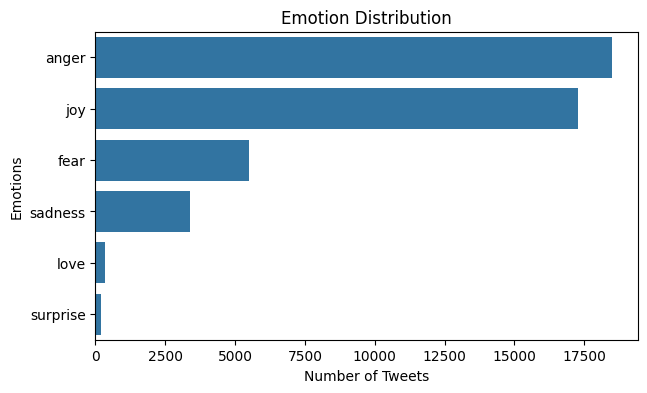

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
sns.countplot(data=df_final, y='emotion', order=df_final['emotion'].value_counts().index)
plt.title("Emotion Distribution")
plt.xlabel("Number of Tweets")
plt.ylabel("Emotions")
plt.show()

### **11.8 Emotion Prediction Confidence Summary**

In [ ]:
high_conf      = df_final[df_final['Score'] >= 0.8]
very_high_conf = df_final[df_final['Score'] >= 0.9]
low_conf       = df_final[df_final['Score'] < 0.6]

print(f"Total Tweets: {len(df_final):,}")
print(f"Very High Confidence (≥90%): {len(very_high_conf):,} ({len(very_high_conf)/len(df_final)*100:.0f}%)")
print(f"High Confidence (≥80%): {len(high_conf):,} ({len(high_conf)/len(df_final)*100:.0f}%)")
print(f"Low Confidence (<60%): {len(low_conf):,} ({len(low_conf)/len(df_final)*100:.0f}%)")

Total Tweets: 45,186
Very High Confidence (≥90%): 18,324 (41%)
High Confidence (≥80%): 25,118 (56%)
Low Confidence (<60%): 9,726 (22%)


### **11.9 Emotion Confidence Score Distribution**

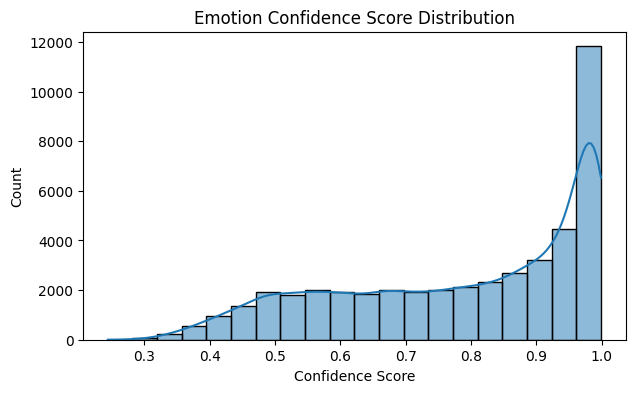

In [ ]:
plt.figure(figsize=(7,4))
sns.histplot(df_final['Score'], bins=20, kde=True)
plt.title("Emotion Confidence Score Distribution")
plt.xlabel("Confidence Score")
plt.ylabel("Count")
plt.show()

### **11.10 Average Confidence Score of Emotions**

In [ ]:
avg_conf = (df_final.groupby('emotion')['Score'].mean().round(4).reset_index())
avg_conf.columns = ['Emotions', 'Average Confidence']

avg_conf

,Emotions,Average Confidence
0,anger,0.7762
1,fear,0.7153
2,joy,0.8182
3,love,0.8167
4,sadness,0.8135
5,surprise,0.8491


### **11.11 High vs. Low Confidence Emotions**

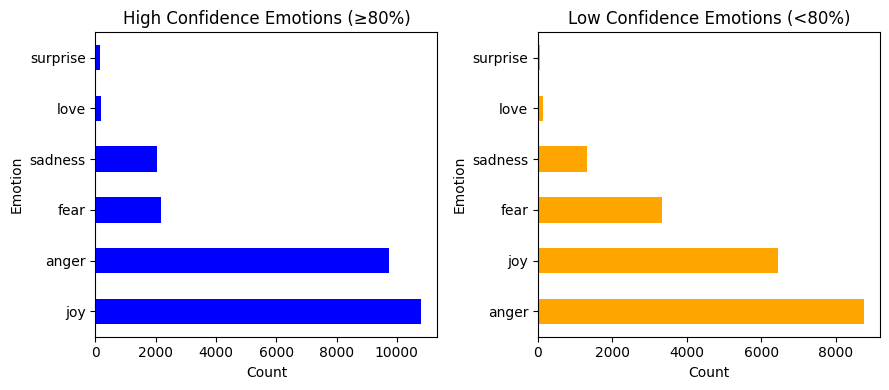

In [ ]:
high_conf = df_final[df_final['Score'] >= 0.8]
low_conf = df_final[df_final['Score'] < 0.8]

plt.figure(figsize=(9,4))
plt.subplot(1,2,1)
high_conf['emotion'].value_counts().plot(kind='barh', color='blue')
plt.title('High Confidence Emotions (≥80%)')
plt.xlabel("Count")
plt.ylabel("Emotion")

plt.subplot(1,2,2)
low_conf['emotion'].value_counts().plot(kind='barh', color='orange')
plt.title('Low Confidence Emotions (<80%)')
plt.xlabel("Count")
plt.ylabel("Emotion")
plt.tight_layout()
plt.show()

### **11.12 Average VADER Polarity Scores per Emotion**

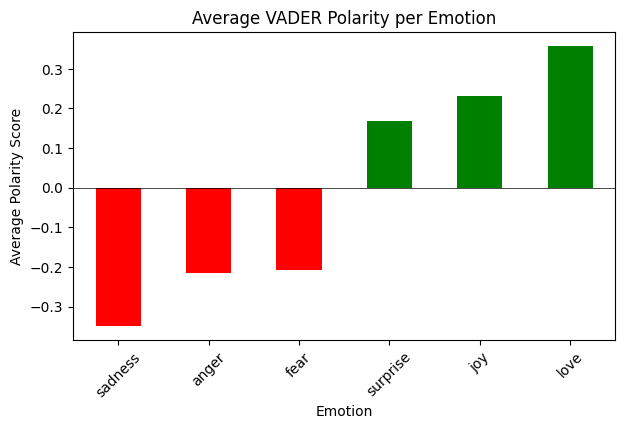

In [ ]:
avg_vader = df_final.groupby('emotion')['VADER_Compound'].mean().sort_values()
colors = ['red' if val < 0 else 'green' for val in avg_vader]

plt.figure(figsize=(7,4))
avg_vader.plot(kind='bar', color=colors)
plt.title("Average VADER Polarity per Emotion")
plt.tick_params(axis='x', rotation=45)
plt.xlabel("Emotion")
plt.ylabel("Average Polarity Score")
plt.axhline(0, color='black', linewidth=0.5)
plt.show()

### **11.13 Sentiment vs. Emotion Relationship**

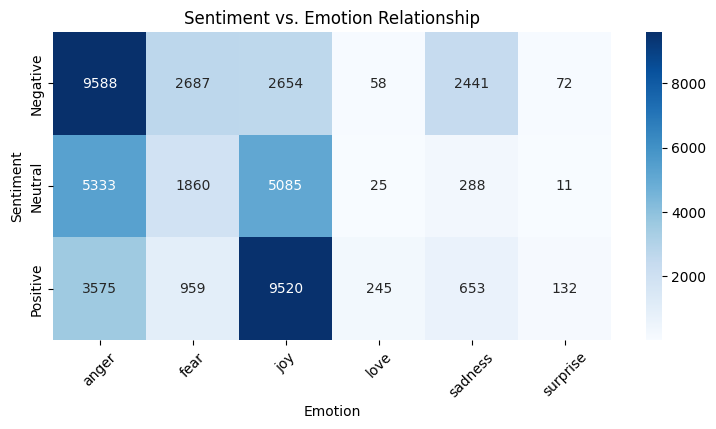

In [ ]:
sent_emotion = pd.crosstab(df_final['Category'], df_final['emotion'])

plt.figure(figsize=(9,4))
sns.heatmap(sent_emotion, annot=True, fmt='d', cmap='Blues')
plt.title("Sentiment vs. Emotion Relationship")
plt.tick_params(axis='x', rotation=45)
plt.xlabel("Emotion")
plt.ylabel("Sentiment")
plt.show()

### **11.14 VADER Scores and Model Confidence by Emotions**

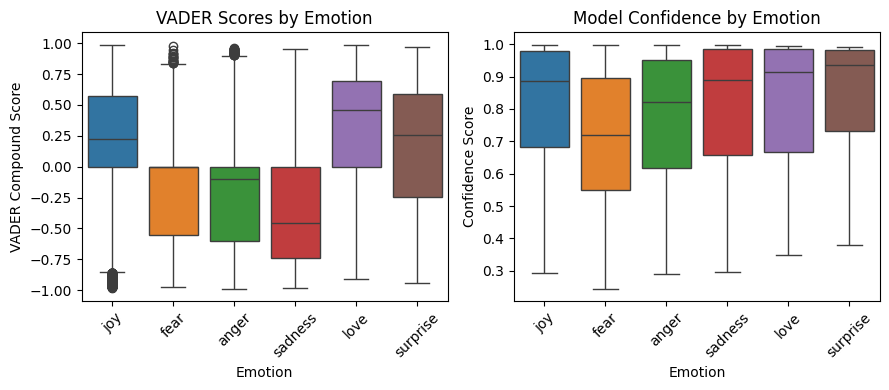

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9,4))

sns.boxplot(data=df_final, x='emotion', y='VADER_Compound', hue='emotion', ax=axes[0])
axes[0].set_title('VADER Scores by Emotion')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('VADER Compound Score')

sns.boxplot(data=df_final, x='emotion', y='Score', hue='emotion', ax=axes[1])
axes[1].set_title('Model Confidence by Emotion')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Confidence Score')

plt.tight_layout()
plt.show()

### **11.15 VADER Sentiment vs. Emotion Model Confidence**

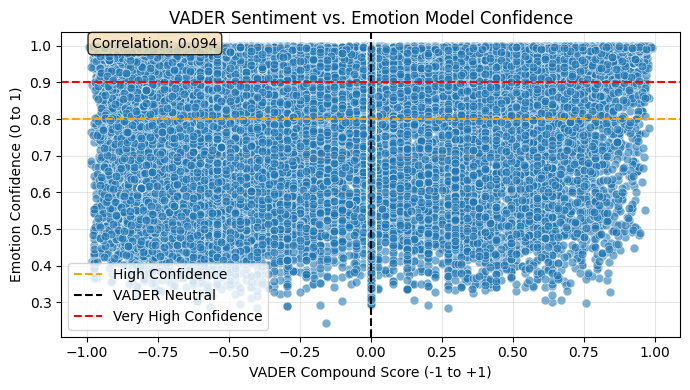

In [ ]:
plt.figure(figsize=(7,4))

sns.scatterplot(data=df_final, x='VADER_Compound', y='Score', alpha=0.6, s=40)
plt.axhline(y=0.8, color='orange', linestyle='--', label='High Confidence')
plt.axvline(x=0, color='black', linestyle='--', label='VADER Neutral')
plt.axhline(y=0.9, color='red', linestyle='--', label='Very High Confidence')

plt.xlabel('VADER Compound Score (-1 to +1)')
plt.ylabel('Emotion Confidence (0 to 1)')
plt.title('VADER Sentiment vs. Emotion Model Confidence')
plt.legend()
plt.grid(True, alpha=0.3)

corr = df_final['VADER_Compound'].corr(df_final['Score'])
plt.text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=plt.gca().transAxes, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

### **11.16 Emotion Confidence Distribution by Category**

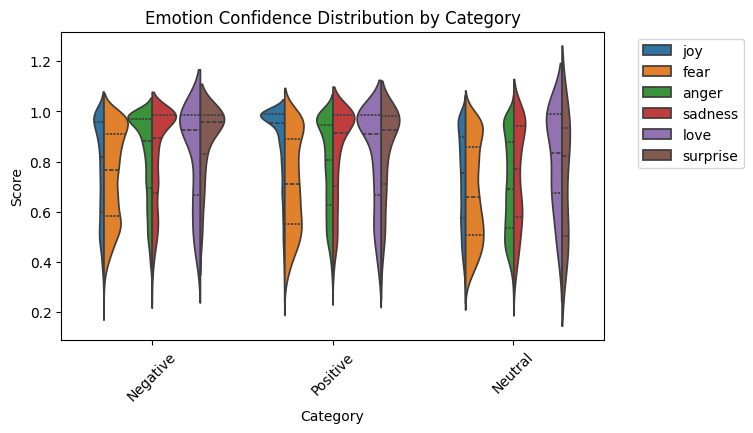

In [ ]:
plt.figure(figsize=(7,4))
sns.violinplot(data=df_final, x='Category', y='Score', hue='emotion', split=True, inner='quart')
plt.title('Emotion Confidence Distribution by Category')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### **11.17 Language Radar Emotion Distribution**

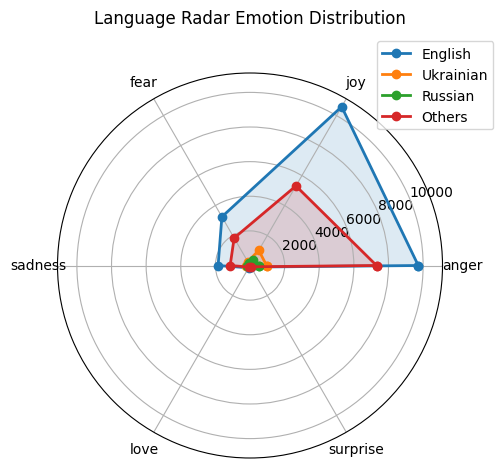

In [ ]:
import numpy as np

selected_languages = ['en', 'uk', 'ru']

df_lang = df_final[df_final['language'].isin(selected_languages)].copy()
df_other = df_final[~df_final['language'].isin(selected_languages)].copy()
df_other['language'] = 'other'
df_lang = pd.concat([df_lang, df_other])

lang_names = {'en': 'English', 'uk': 'Ukrainian', 'ru': 'Russian', 'other': 'Others'}
all_emotions = df_final['emotion'].value_counts().index
lang_all = (df_lang.groupby(['language', 'emotion']).size().unstack(fill_value=0))

angles = np.linspace(0, 2*np.pi, len(all_emotions), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8,5), subplot_kw=dict(projection='polar'))

for lang in ['en', 'uk', 'ru', 'other']:
    if lang in lang_all.index:
        values = lang_all.loc[lang].reindex(all_emotions, fill_value=0).tolist()
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=lang_names[lang])
        ax.fill(angles, values, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(all_emotions)

plt.title('Language Radar Emotion Distribution\n\n')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1.10))
plt.show()

# **12. Multilingual Emotion-Sentiment Analyzer**

In [ ]:
!pip install langdetect deep-translator

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 19.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 2.6 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=e5135955dc6721054f8128d5770f07598e1438be796f491d5526e63f1c1e6ad3
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [ ]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
from transformers.utils import logging
from transformers import pipeline
logging.set_verbosity_error()

emotion_model = pipeline("text-classification", model="bhadresh-savani/bert-base-uncased-emotion", top_k=None)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
import os
os.environ["GRADIO_ANALYTICS_ENABLED"] = "False"
os.environ["GRADIO_WARNING"] = "False"

import gradio as gr
from langdetect import detect, DetectorFactory
from deep_translator import GoogleTranslator
from nltk.sentiment import SentimentIntensityAnalyzer

import re
def clean_tweet(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

DetectorFactory.seed = 0
analyzer = SentimentIntensityAnalyzer()
translator = GoogleTranslator(source='auto', target='en')

Language_names = {
"en":"English","de":"German","fr":"French","it":"Italian","es":"Spanish","fi":"Finnish","et":"Estonian","lt":"Lithuanian",
"tr":"Turkish","pt":"Portuguese","no":"Norwegian","pl":"Polish","id":"Indonesian","nl":"Dutch","sw":"Swahili","sl":"Slovenian",
"ca":"Catalan","hr":"Croatian","af":"Afrikaans","und":"Undefined","uk":"Ukrainian","ru":"Russian","ja":"Japanese","zh":"Chinese",
"el":"Greek","hi":"Hindi","ar":"Arabic","ro":"Romanian","bn":"Bengali","ta":"Tamil","te":"Telugu","ml":"Malayalam",
"kn":"Kannada","mr":"Marathi","gu":"Gujarati","pa":"Punjabi","ur":"Urdu","or":"Odia"}

Emotion_map = {
    "joy": "HAPPINESS 😊", "sadness": "SADNESS 😢",
    "anger": "ANGER 😡", "fear": "FEAR 😨",
    "love": "LOVE ❤️", "surprise": "SURPRISE 😮"}

def detect_language(text):
    try:
        code = detect(text)
        name = Language_names.get(code, "Unknown")
        return code, name
    except:
        return "unknown", "Unknown"

def detect_emotion(text):
    try:
        results = emotion_model(text)[0]
        best = max(results, key=lambda x: x['score'])
        raw_label = best['label']
        mapped_label = Emotion_map.get(raw_label.lower(), raw_label.upper())
        return mapped_label, round(best['score'], 3)
    except:
        return "UNKNOWN", 0.0

def ultimate_translator(text):
    if not text.strip():
        return "Please enter some text"
    lang_code, lang_name = detect_language(text)
    try:
        translated = translator.translate(text)
    except:
        translated = text

    cleaned = clean_tweet(translated)
    scores = analyzer.polarity_scores(cleaned)
    emotion, emo_score = detect_emotion(cleaned)

    if scores['compound'] > 0.05:
        sentiment = "POSITIVE 😊"
    elif scores['compound'] < -0.05:
        sentiment = "NEGATIVE 😠"
    else:
        sentiment = "NEUTRAL 😐"

    breakdown = {
        'pos': round(scores['pos'],3),
        'neu': round(scores['neu'],3),
        'neg': round(scores['neg'],3)}

    return f"""
### 🌐 Language Detected:
**{lang_name} ({lang_code})**

### 🔁 Translation:
`{translated}`

### 🧹 Cleaned Text:
`{cleaned}`

### 📊 VADER Score:
**Breakdown:** {breakdown}
**Compound:** {scores['compound']:.3f}

### 🧠 Emotion Detected:
**Label:** {emotion}
**Score:** {emo_score:.3f}

### 🎯 Sentiment:
### {sentiment}
"""

demo = gr.Interface(
    fn=ultimate_translator,
    inputs=gr.Textbox(
        label="Enter a text in any language:",
        placeholder="Type here..."),
    outputs=gr.Markdown(),
    title="UNIVERSAL LANGUAGE EMOTION & SENTIMENT ANALYZER",
    description="""
<div align="center">

### (45K+ Multilingual Tweets Trained Pipeline)
</div>

""",
    flagging_mode="never")

demo.launch(share=True, quiet=True)

* Running on public URL: https://06b00fde0be0d67e60.gradio.live


In [ ]:
যুদ্ধের মাঝেও মানুষ একে অপরকে সাহায্য করছে 🤝 humanity এখনো বেঁচে আছে, শীঘ্রই শান্তি ফিরবে...🕊️🌎
#শান্তি #Hope #মানবতা #StandWithPeople